# 1. ANN on Iris Dataset

In [ ]:
# Importing necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
pip install tensorflow

In [62]:
# Loading the Iris dataset
iris = load_iris()
X = iris.data                     # Features: petal and sepal dimensions
y = iris.target.reshape(-1, 1)    # Target: Flower species

In [64]:
y

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
    

In [66]:
# One-hot encoding the target labels
encoder = OneHotEncoder()
y_encoded = encoder.fit_transform(y).toarray()

In [68]:
y_encoded

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

In [70]:
# Standardizing the features for better performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [72]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)


In [74]:
# Building the neural network (Forward Propagation)
model = Sequential([
    Dense(8, input_dim=4, activation='relu'),  # Hidden layer with 8 neurons
    Dense(16, activation='relu'),  # Hidden layer with 8 neurons
    Dense(64, activation='relu'),  # Hidden layer with 16 neurons
    Dense(8, activation='relu'),  # Hidden layer with 8 neurons
    Dense(3, activation='softmax')            # Output layer with 3 neurons (one per class)
])

In [76]:
# Compiling the model (Backword Propagation)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [78]:
# Training the model
model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=0)


In [79]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Test Accuracy: 100.00%


In [80]:
# Making predictions
predictions = model.predict(X_test[:5])
predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(y_test[:5], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


In [81]:
# Displaying predictions
for i, (pred, actual) in enumerate(zip(predicted_classes, actual_classes)):
    print(f"Sample {i+1}: Predicted = {iris.target_names[pred]}, Actual = {iris.target_names[actual]}")

Sample 1: Predicted = versicolor, Actual = versicolor
Sample 2: Predicted = setosa, Actual = setosa
Sample 3: Predicted = virginica, Actual = virginica
Sample 4: Predicted = versicolor, Actual = versicolor
Sample 5: Predicted = versicolor, Actual = versicolor


# 2. ANN on MNIST Dataset

In [86]:
# Importing necessary libraries
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [88]:
# Loading the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

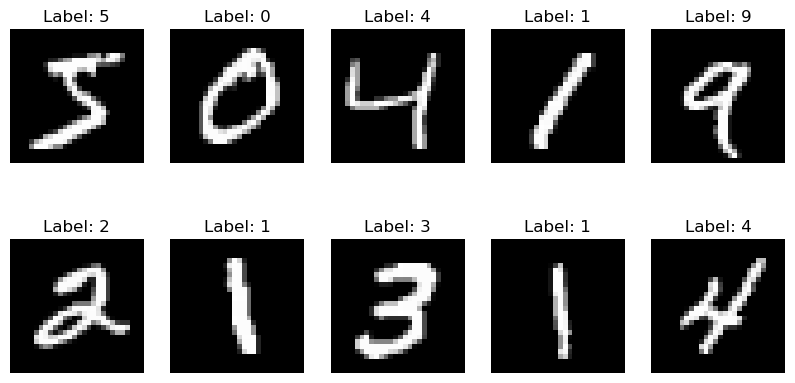

In [90]:
# Visualizing some images from the dataset
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [92]:
# Preprocessing the data
X_train = X_train / 255.0  # Normalize pixel values to [0, 1]
X_test = X_test / 255.0
y_train = to_categorical(y_train, 10)  # One-hot encode the labels
y_test = to_categorical(y_test, 10)

In [94]:
# Building the neural network
model = Sequential([
    Flatten(input_shape=(28, 28)),          # Flatten 28x28 images into 1D arrays
    Dense(128, activation='relu'),         # Hidden layer with 128 neurons
    Dense(60, activation='relu'),         # Hidden layer with 60 neurons
    Dense(10, activation='softmax')        # Output layer with 10 neurons (one per class)
])

In [96]:
# Compiling the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [98]:
# Training the model
model.fit(X_train, y_train, epochs=4, batch_size=32, verbose=1)


Epoch 1/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8848 - loss: 0.4064
Epoch 2/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9684 - loss: 0.1051
Epoch 3/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9778 - loss: 0.0718
Epoch 4/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9833 - loss: 0.0539


In [100]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 97.31%


In [102]:
# Testing the model with some examples
predictions = model.predict(X_test[0:5])
for i, prediction in enumerate(predictions):
    predicted_class = prediction.argmax()
    actual_class = y_test[i].argmax()
    print(f"Sample {i+1}: Predicted = {predicted_class}, Actual = {actual_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Sample 1: Predicted = 7, Actual = 7
Sample 2: Predicted = 2, Actual = 2
Sample 3: Predicted = 1, Actual = 1
Sample 4: Predicted = 0, Actual = 0
Sample 5: Predicted = 4, Actual = 4


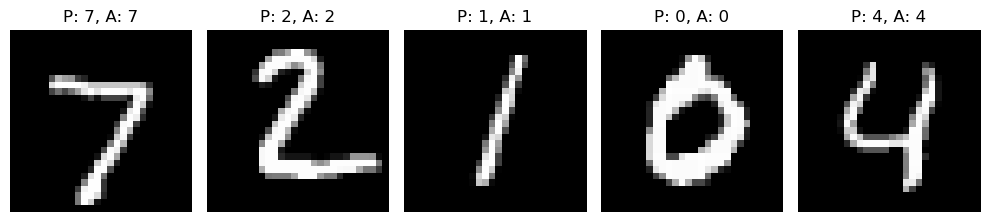

In [104]:
# Visualizing predictions
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i], cmap='gray')
    predicted_class = np.argmax(predictions[i])
    actual_class = np.argmax(y_test[i])
    plt.title(f"P: {predicted_class}, A: {actual_class}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [106]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 60)             │         7,740 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,492 (1.25 MB)

 Trainable params: 108,830 (425.12 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 217,662 (850.25 KB)

In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# -------------------------------
# Parameters
# -------------------------------
n_days = 30        # number of days
interval = 1       # hourly data
panel_capacity = 100  # kW
panel_efficiency = 0.18  # 18%
inverter_efficiency = 0.95  # 95%
latitude, longitude = 19.07, 72.87  # Example: Mumbai

# -------------------------------
# Helper Functions
# -------------------------------
def solar_irradiance(hour, cloud_cover):
    """Synthetic irradiance pattern: bell curve over the day"""
    if hour < 6 or hour > 18:
        return 0  # night
    peak = 1000  # max irradiance W/m² at noon (clear sky)
    irradiance = peak * np.exp(-0.5 * ((hour - 12) / 3) ** 2)
    irradiance *= (1 - cloud_cover / 100)  # reduce due to cloud cover
    return irradiance

def temp_efficiency(temp):
    """Efficiency drop when temp > 25°C"""
    if temp <= 25:
        return 1
    else:
        return 1 - 0.005 * (temp - 25)  # 0.5% drop per degree

# -------------------------------
# Generate Data
# -------------------------------
data = []
start_date = datetime(2025, 1, 1)

for day in range(n_days):
    for hour in range(0, 24, interval):
        date = start_date + timedelta(days=day, hours=hour)
        
        # Weather & environmental conditions
        temperature = np.random.uniform(20, 40)   # °C
        humidity = np.random.uniform(30, 90)      # %
        cloud_cover = np.random.uniform(0, 100)   # %
        wind_speed = np.random.uniform(0, 10)     # m/s
        tilt_angle = 20                           # fixed tilt
        azimuth_angle = 180                       # south facing
        
        # Irradiance calculation
        irradiance = solar_irradiance(hour, cloud_cover)
        
        # Effective efficiencies
        effective_eff = (panel_efficiency * inverter_efficiency *
                         temp_efficiency(temperature))
        
        # Power Output (kWh for that hour)
        solar_power = (irradiance/1000) * panel_capacity * effective_eff
        
        data.append([
            date.date(), date.time(), latitude, longitude,
            round(temperature,2), round(humidity,2), round(cloud_cover,2),
            round(irradiance,2), round(wind_speed,2), panel_capacity,
            panel_efficiency, tilt_angle, azimuth_angle, inverter_efficiency,
            round(solar_power,2)
        ])

# -------------------------------
# Create DataFrame
# -------------------------------
columns = ["Date", "Time", "Latitude", "Longitude", "Temperature", "Humidity", "Cloud_Cover",
           "Irradiance", "Wind_Speed", "Panel_Capacity", "Panel_Efficiency",
           "Tilt_Angle", "Azimuth_Angle", "Inverter_Efficiency", "Solar_Power_Output (kWh)"]

df = pd.DataFrame(data, columns=columns)

# Preview
print(df.head())

# Save to CSV
df.to_csv("synthetic_solar_power.csv", index=False)
